In [16]:
import pandas as pd
import numpy as np
import re
import string
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.20.0


In [17]:
fake = pd.read_csv("Fake.csv")
true = pd.read_csv("True.csv")

In [18]:
fake["label"] = 0
true["label"] = 1

In [19]:
df = pd.concat([fake, true], ignore_index=True)

In [20]:
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

In [21]:
df.head()

,title,text,subject,date,label
0,Ben Stein Calls Out 9th Circuit Court: Committ...,"21st Century Wire says Ben Stein, reputable pr...",US_News,"February 13, 2017",0
1,Trump drops Steve Bannon from National Securit...,WASHINGTON (Reuters) - U.S. President Donald T...,politicsNews,"April 5, 2017",1
2,Puerto Rico expects U.S. to lift Jones Act shi...,(Reuters) - Puerto Rico Governor Ricardo Rosse...,politicsNews,"September 27, 2017",1
3,OOPS: Trump Just Accidentally Confirmed He Le...,"On Monday, Donald Trump once again embarrassed...",News,"May 22, 2017",0
4,Donald Trump heads for Scotland to reopen a go...,"GLASGOW, Scotland (Reuters) - Most U.S. presid...",politicsNews,"June 24, 2016",1


In [22]:
print(df.shape)

(44898, 5)


In [23]:
df["content"] = df["title"] + " " + df["text"]

In [24]:
df = df[["content", "label"]]

In [25]:
df.head()

,content,label
0,Ben Stein Calls Out 9th Circuit Court: Committ...,0
1,Trump drops Steve Bannon from National Securit...,1
2,Puerto Rico expects U.S. to lift Jones Act shi...,1
3,OOPS: Trump Just Accidentally Confirmed He Le...,0
4,Donald Trump heads for Scotland to reopen a go...,1


In [26]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"www\S+", "", text)
    text = re.sub(r"<.*?>", "", text)
    text = re.sub(r"[^a-zA-Z]", " ", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()

In [27]:
df["content"] = df["content"].apply(clean_text)

In [28]:
df.head()

,content,label
0,ben stein calls out th circuit court committed...,0
1,trump drops steve bannon from national securit...,1
2,puerto rico expects u s to lift jones act ship...,1
3,oops trump just accidentally confirmed he leak...,0
4,donald trump heads for scotland to reopen a go...,1


In [29]:
X = df["content"]
y = df["label"]

In [30]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [31]:
max_words = 50000

tokenizer = Tokenizer(num_words=max_words, oov_token="<OOV>")

tokenizer.fit_on_texts(X_train)

In [32]:
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

In [33]:
max_length = 300

X_train_pad = pad_sequences(
    X_train_seq,
    maxlen=max_length,
    padding='post',
    truncating='post'
)

X_test_pad = pad_sequences(
    X_test_seq,
    maxlen=max_length,
    padding='post',
    truncating='post'
)

In [34]:
print(X_train_pad.shape)
print(X_test_pad.shape)

(35918, 300)
(8980, 300)


In [35]:
model = Sequential()

# Embedding Layer
model.add(Embedding(input_dim=max_words, output_dim=128))

# BiLSTM Layer
model.add(Bidirectional(LSTM(64, return_sequences=False)))

# Dropout Layer
model.add(Dropout(0.5))

# Hidden Dense Layer
model.add(Dense(64, activation='relu'))

# Output Layer
model.add(Dense(1, activation='sigmoid'))

In [36]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [37]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding (Embedding)                │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional (Bidirectional)        │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [38]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

In [39]:
history = model.fit(
    X_train_pad,
    y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stop]
)

Epoch 1/10
449/449 ━━━━━━━━━━━━━━━━━━━━ 192s 405ms/step - accuracy: 0.9819 - loss: 0.0456 - val_accuracy: 0.9994 - val_loss: 0.0019
Epoch 2/10
449/449 ━━━━━━━━━━━━━━━━━━━━ 195s 434ms/step - accuracy: 0.9995 - loss: 0.0024 - val_accuracy: 0.9993 - val_loss: 0.0016
Epoch 3/10
449/449 ━━━━━━━━━━━━━━━━━━━━ 199s 444ms/step - accuracy: 0.9999 - loss: 7.9901e-04 - val_accuracy: 0.9990 - val_loss: 0.0043
Epoch 4/10
449/449 ━━━━━━━━━━━━━━━━━━━━ 195s 429ms/step - accuracy: 0.9999 - loss: 7.5836e-04 - val_accuracy: 0.9992 - val_loss: 0.0046
Epoch 5/10
449/449 ━━━━━━━━━━━━━━━━━━━━ 186s 414ms/step - accuracy: 0.9995 - loss: 0.0014 - val_accuracy: 0.9996 - val_loss: 0.0017


In [40]:
loss, accuracy = model.evaluate(X_test_pad, y_test)

print("Test Loss:", loss)
print("Test Accuracy:", accuracy)

281/281 ━━━━━━━━━━━━━━━━━━━━ 50s 176ms/step - accuracy: 0.9992 - loss: 0.0028 
Test Loss: 0.002775224857032299
Test Accuracy: 0.9992204904556274


In [41]:
y_pred = model.predict(X_test_pad)

y_pred = (y_pred > 0.5).astype(int)

281/281 ━━━━━━━━━━━━━━━━━━━━ 57s 196ms/step


In [42]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      4696
           1       1.00      1.00      1.00      4284

    accuracy                           1.00      8980
   macro avg       1.00      1.00      1.00      8980
weighted avg       1.00      1.00      1.00      8980



In [43]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[4694    2]
 [   5 4279]]


In [44]:
model.save("fake_news_bilstm.keras")

In [45]:
import pickle

with open("tokenizer.pkl", "wb") as file:
    pickle.dump(tokenizer, file)

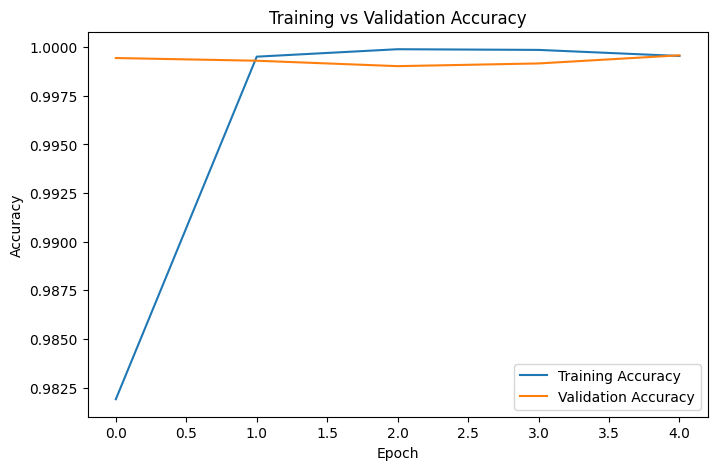

In [46]:
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()

plt.show()

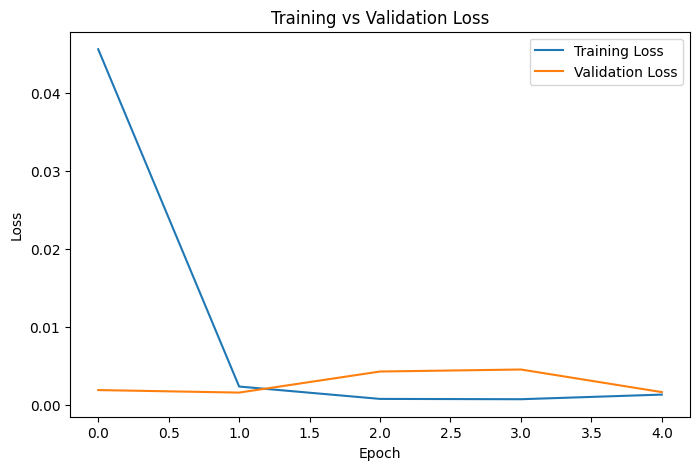

In [47]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()

plt.show()